## オブジェクト指向

In [7]:
import random
import matplotlib.pyplot as plt

class RandomWoker:
    def __init__(self, speed = 1.0):
        self.position = 0.0 # 現在地
        self.speed = speed # ランダムウォークする移動量
        self.trajectory = [self.position] # ランダムウォークの軌跡

    def walk(self):
        # ランダムに移動するロジック（1 or -1）
        n = random.choice([-1, 1])
        # 移動
        self.position += n * self.speed
        # 軌跡に現在地を追加
        self.trajectory.append(self.position)

    def plot_trajectory(self):
        # ランダムウォークした軌跡をグラフ化する
        plt.figure(figsize=(6, 4))
        plt.plot(self.trajectory, marker='o')
        plt.title(f'Random Walk Trajectory (speed = {self.speed})', fontsize = 14)
        plt.xlabel('Step', fontsize = 12)
        plt.ylabel('Position', fontsize = 12)
        plt.show()


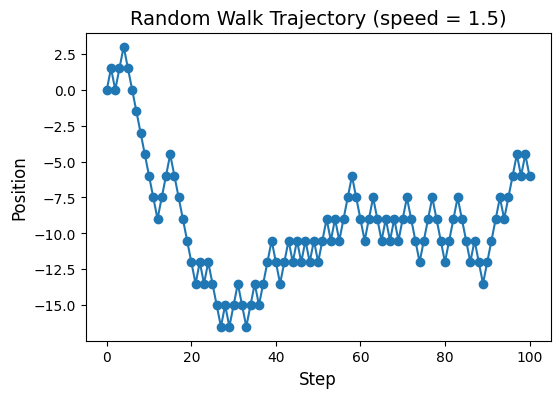

In [8]:
speed = 1.5
rw = RandomWoker(speed)
# ランダムウォークを100ステップ行う
for _ in range(100):
    rw.walk()
# ランダムウォークの軌跡をプロットする
rw.plot_trajectory()

## 格子上での進化ゲーム

https://github.com/igenki/biomathNL/blob/master/04/SpEvolGame.ipynb

In [9]:
class Agent:
    def __init__(self):
        """Agentの初期設定"""
        # 協力か非協力かをランダムに決定
        self.strategy = random.choice(['C', 'D']) # C: 協力, D: 非協力
        # 更新後に使う戦略
        self.next_strategy = None
        # 利得の初期化
        self.reset()

    def reset(self) -> None:
        """Agentの利得をリセットする"""
        self.payoff = 0 

    def get_payoff(self, p: float) -> None:
        """Agentの利得を更新する"""
        self.payoff += p

    def select_next_strategy_IoS(self, neighbors: list, pmatrix: dict) -> None:
        """
        IoS : 成功の模倣 (Imitation of Success)
         - 自分と近隣のエージェントの中で最も利得が高いエージェントを見つけ、その戦略を次の世代の戦略として採用する。
        """
        list_with_me = neighbors + [self]
        # 同じ利得がいる場合に備えて、参照額をシャッフル
        random.shuffle(list_with_me)
        # 最も利得が高いエージェントを見つける
        max_agent = list_with_me[0] # 初期値
        for i in range(1, len(list_with_me)):
            a = list_with_me[i]
            if a.payoff > max_agent.payoff:
                max_agent = a
        # 最も利得が高いエージェントの戦略をメモ
        self.next_strategy = max_agent.strategy

    def select_next_strategy_BR(self, neighbors: list, pmatrix: dict) -> None:
        """
        Best Response : 最適反応
        - 近隣の戦略分布に対して、利得が最大になる戦略を次世代の戦略として選ぶ
        """

        # 近隣の協力者, 非協力者数を数える
        n_C = sum(1 for agent in neighbors if agent.strategy == 'C')
        n_D = len(neighbors) - n_C

        # 自分が C, D を選んだときの総利得
        payoff_C = n_C * pmatrix[('C', 'C')] + n_D * pmatrix[('C', 'D')]
        payoff_D = n_C * pmatrix[('D', 'C')] + n_D * pmatrix[('D', 'D')]

        # 利得が高い方の戦略を次世代に採用
        if payoff_C > payoff_D:
            self.next_strategy = 'C'
        elif payoff_D > payoff_C:
            self.next_strategy = 'D'
        else:
            # 同点ならランダムに選ぶ
            self.next_strategy = random.choice(['C', 'D'])
    
    def update_strategy(self) -> None:
        """Agentの戦略を更新する"""
        self.strategy = self.next_strategy

In [10]:
class Game:
    def __init__(self, L: int=50):
        """EvolGameの初期設定"""
        # 格子の一辺の長さ
        self.L = L
        # ゲームの利得行列
        self.pmatrix = {
            ('C', 'C'): 5, # 相互協力
            ('C', 'D'): 0, # 自分が協力, 相手が非協力
            ('D', 'C'): 6, # 自分が非協力, 相手が協力
            ('D', 'D'): 1  # 相互非協力
        }
        # 格子上のエージェントのリスト
        self.agent_list = [[Agent() for _ in range(L)] for _ in range(L)]

    def reset(self) -> None:
        """全エージェントの利得をリセットする"""
        for i in self.agent_list:
            for a in i:
                a.reset()

    def play_game(self) -> None:
        """全エージェントの利得を更新する"""
        # 各エージェントの処理
        for i, l in enumerate(self.agent_list):
            for j, focal in enumerate(l):
                # エージェント focal の処理

                def get_payoff(focal: Agent, opp: Agent) -> None:
                    """
                    互いの戦略からゲームの利得を得て、focal (自分) と opp (相手) の利得を更新する
                    """
                    p_focal = self.pmatrix[(focal.strategy, opp.strategy)]
                    p_opp = self.pmatrix[(opp.strategy, focal.strategy)]

                    # focal の利得を更新
                    focal.get_payoff(p_focal)
                    # opp へ利得を更新
                    opp.get_payoff(p_opp)
                
                # 左隣のエージェント
                opp1 = self.agent_list[i][j-1]
                get_payoff(focal, opp1)

                # 上隣のエージェント
                opp2 = self.agent_list[i-1][j]
                get_payoff(focal, opp2)

    def select_next_strategy(self) -> None:
        """全エージェントの次世代の戦略を選ぶ"""
        for i, l in enumerate(self.agent_list):
            for j, focal in enumerate(l):

                # 隣人のAgentのリストを作成
                neighbors = [
                    self.agent_list[i-1][j], # 上
                    self.agent_list[i][j-1], # 左
                    # -L で末尾からアクセスする（out of range を防ぐ）
                    self.agent_list[i+1-self.L][j], # 下
                    self.agent_list[i][j+1-self.L] # 右
                ]

                # 隣人の戦略の中で最も利得の高い戦略を選ぶ
                focal.select_next_strategy_IoS(neighbors, self.pmatrix)
                # focal.select_next_strategy_BR(neighbors, self.pmatrix)
    
    def update_strategy(self) -> None:
        """全エージェントの戦略を更新する"""
        for l in self.agent_list:
            for a in l:
                a.update_strategy()

### シミュレーション (協力者の割合をプロット)

********** 100%


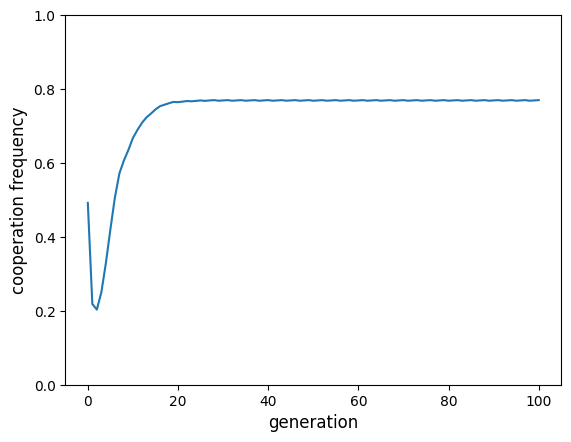

In [11]:
def calc_C_frequency(agent_list: list[list[Agent]]) -> float:
    """協力者 (C) の割合を計算する"""
    nC = 0 # 協力者人数
    for l in agent_list:
        for focal in l:
            if focal.strategy == 'C':
                nC += 1

    # エージェント総数（L×L）で割って協力者割合を返す
    return nC / (len(agent_list) * len(agent_list[0]))

def simulate(Tmax = 100, L = 50) -> None:
    """シミュレーションを実行する"""
    game = Game(L) # ゲームの初期化
    # 協力者割合を記録
    fC_list = [calc_C_frequency(game.agent_list)]

    # 世代を Tmax 回繰り返す
    for i in range(Tmax):
        game.reset() # エージェントの利得をリセット
        game.play_game() # エージェント同士でゲームを行い、利得を計算
        game.select_next_strategy() # 次世代の戦略を選ぶ
        game.update_strategy() # 戦略を更新

        fC_list.append(calc_C_frequency(game.agent_list)) # 協力者割合を記録

        # 進捗確認用のバーを表示
        t = Tmax / 10
        if (i+1)%t == 0:
            print("*"*int((i+1)/t) + 
                "_"*(10-int((i+1)/t)), 
                f"{int((i+1)/Tmax*100):3d}%",  
                end='\r' if (i+1)<Tmax else '\n')
    
    return fC_list

def plot_fC(fC_list: list[float]) -> None:
    # 協力者割合の推移をグラフ化する
    plt.ylim(0,1)
    plt.xlabel('generation', fontsize=12)
    plt.ylabel('cooperation frequency', fontsize=12)
    plt.plot(fC_list)

fC_list = simulate(Tmax=100, L=50)
plot_fC(fC_list)

### シミュレーション (格子の状態をプロット)

Initial State


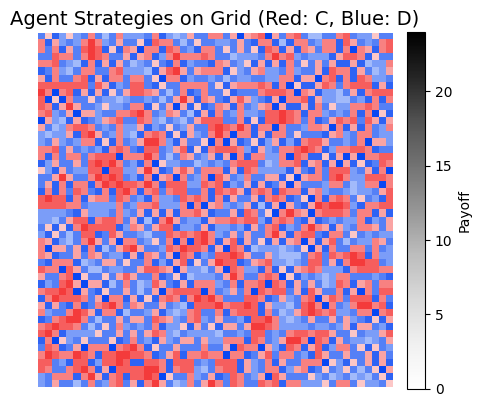

Generation 2


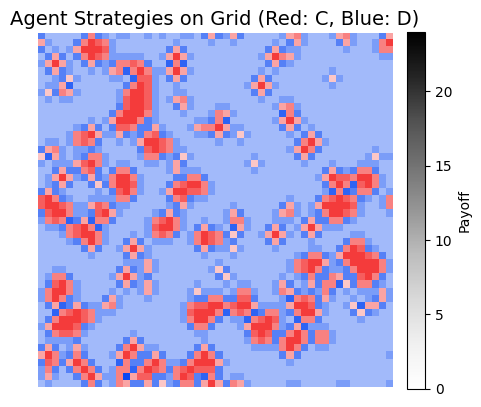

Generation 4


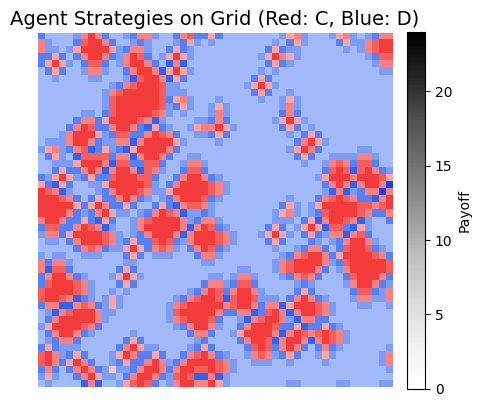

Generation 6


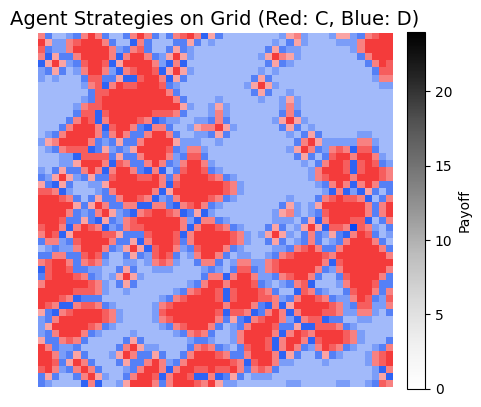

Generation 8


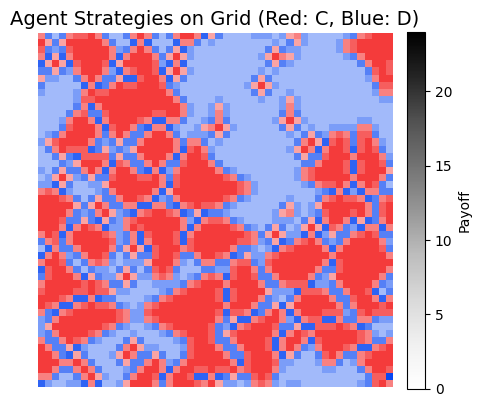

Generation 10


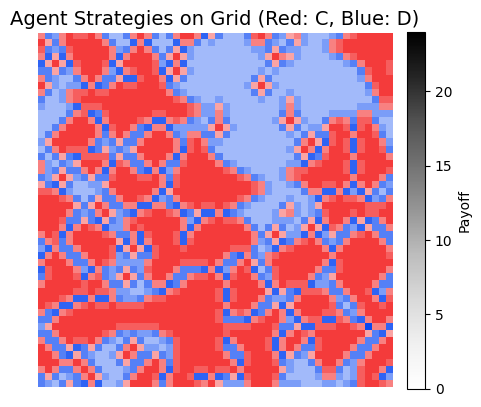

Generation 12


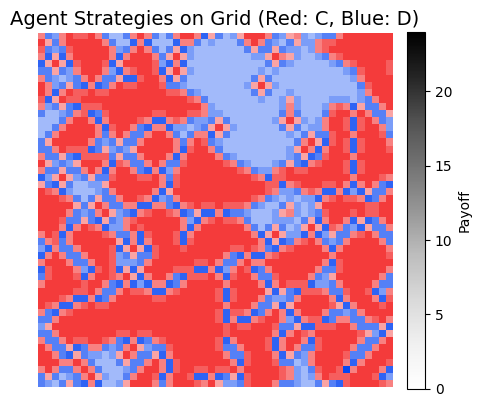

Generation 14


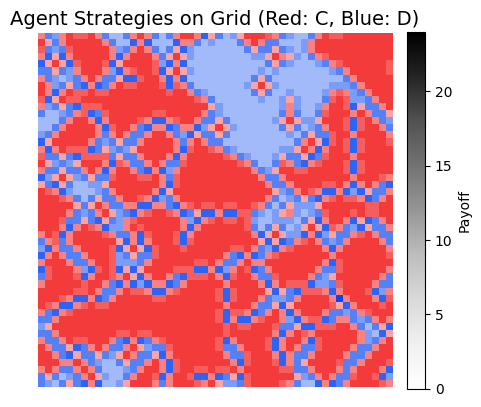

Generation 16


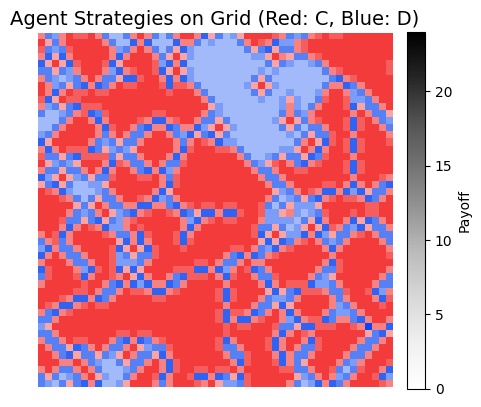

Generation 18


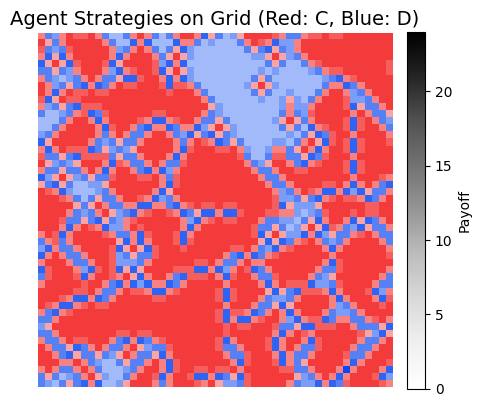

Generation 20


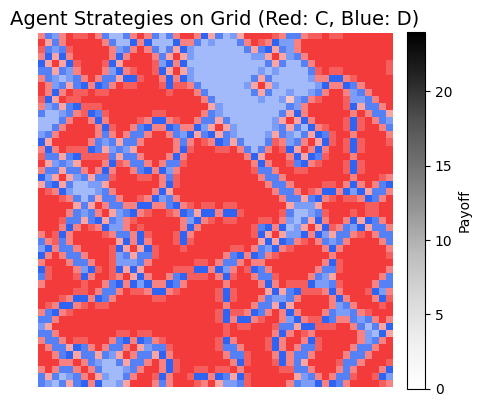

In [12]:
from matplotlib.colors import Normalize, to_rgb

def range_payoff(pmatrix: dict, neighbor_count: int = 4) -> tuple[float, float]:
    """一人当たりの総利得の範囲 (最小値, 最大値) を計算"""
    min_payoff = min(pmatrix.values()) * neighbor_count
    max_payoff = max(pmatrix.values()) * neighbor_count
    return min_payoff, max_payoff

def plot_grid(agent_list: list[list[Agent]], min_payoff: float, max_payoff: float) -> None:
    """
    格子上のエージェントの戦略と利得を色で表現してプロットする

    - 戦略は色相、利得は色の濃さで表現する
    - 利得の正規化には、その世代の最小・最大ではなく、利得表から考えられる理論上の最小・最大を使う
    """
    color_dict = {'C': to_rgb("#f32020f9"), 'D': to_rgb("#0847f3")}
    rgb_grid = []
    for l in agent_list:
        rgb_row = []
        for a in l:
            if max_payoff == min_payoff:
                payoff_strength = 1.0
            else:
                payoff_strength = (a.payoff - min_payoff) / (max_payoff - min_payoff)
                # 念のため、計算誤差や想定外の値があっても0から1の範囲に収める
                payoff_strength = min(max(payoff_strength, 0), 1)
            # 利得が最小でも完全な白にはせず、戦略の色が少し見えるようにする
            strength = 0.25 + 0.75 * payoff_strength
            base_color = color_dict[a.strategy]
            # 白から戦略色へ近づけることで、利得が高いほど色を濃くする
            rgb_row.append(tuple(1 - strength * (1 - c) for c in base_color))
        rgb_grid.append(rgb_row)

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(rgb_grid)
    ax.set_title('Agent Strategies on Grid (Red: C, Blue: D)', fontsize = 14)
    ax.axis('off') # 軸を非表示にする

    if max_payoff == min_payoff:
        norm = Normalize(vmin=min_payoff - 0.5, vmax=max_payoff + 0.5)
    else:
        norm = Normalize(vmin=min_payoff, vmax=max_payoff)
    sm = plt.cm.ScalarMappable(
        cmap='Greys',
        norm=norm
    )
    fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04, label='Payoff')
    plt.show()

def simulate(Tmax = 100, L = 50, split_n = 2) -> None:
    """格子上のエージェントをplot_gridで可視化しながらシミュレーションを実行する"""
    game = Game(L)
    # 色の濃さを世代間で比較できるように、利得表から固定の正規化範囲を作る
    min_payoff, max_payoff = range_payoff(game.pmatrix)
    game.reset() # エージェントの利得をリセットする
    game.play_game() # 初期状態の利得を計算する

    print('Initial State')
    plot_grid(game.agent_list, min_payoff, max_payoff) # 初期状態の格子をプロットする
    for i in range(Tmax):
        game.select_next_strategy() # 全エージェントの次世代の戦略を選ぶ
        game.update_strategy() # 全エージェントの戦略を更新する
        game.reset() # エージェントの利得をリセットする
        game.play_game() # 更新後の戦略でゲームの利得を計算する
        # split_n世代ごとに格子をプロットする
        if (i+1) % split_n == 0:
            print(f'Generation {i+1}')
            plot_grid(game.agent_list, min_payoff, max_payoff)

simulate(Tmax=20, L=50, split_n=2)

### シミュレーション結果

```python
('C', 'C'): 5, # 相互協力
('C', 'D'): 0, # 自分が協力, 相手が非協力
('D', 'C'): 6, # 自分が非協力, 相手が協力
('D', 'D'): 1  # 相互非協力
```

協力非協力の戦略も、上記のゲームの利得表だと**協力者**が多いほど利得が増える。ただし、同じ近傍構成なら常に非協力者の方が協力者より高利得である。そのため初期には非協力が広がりやすい。一方で、非協力者が増えて周囲も非協力者ばかりになると、非協力者同士の利得は低くなる。そのため、初期のランダム配置の中で形成された協力者集団が一定規模で生き残ると、その内部では高い利得を維持できるため、周囲の低利得な非協力者より有利になり、集団として拡大していく結果になった。